# Chapter(3)
Here in this chapter, we are going to explore some classification problems, and we are going to use MNIST dataset, to explore some Machine Learning classification programs.

In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.datasets import fetch_openml

In [3]:
from scipy.io import loadmat
#data = loadmat(r"C:\Users\mo7am\scikit_learn_data\openml\datasets\554\mnist.mat")
X = data["data"].T
y = data["label"].T.reshape(70_000)

NameError: name 'data' is not defined

In [4]:
mnist = fetch_openml('mnist_784', as_frame=False, n_retries=5, delay=5)
X, y = mnist.data, mnist.target

The `sklearn.datasets` package contains mostly three types of functions:

1. **`fetch_*` functions** — such as `fetch_openml()` — to download real-life datasets.

2. **`load_*` functions** — to load small toy datasets bundled with Scikit-Learn (so they don’t need to be downloaded over the internet).

3. **`make_*` functions** — to generate fake datasets, useful for tests.

Generated datasets are usually returned as an `(X, y)` tuple containing the input data and the targets, both as NumPy arrays.

Other datasets are returned as `sklearn.utils.Bunch` objects, which are dictionaries whose entries can also be accessed as attributes.  
They generally contain the following entries:


In [5]:
pd.Series(y.reshape(70000)).describe

<bound method NDFrame.describe of 0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Length: 70000, dtype: object>

In [6]:
# X, y = mnist.data, mnist.target

In [7]:
import matplotlib.pyplot as plt

In [8]:
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

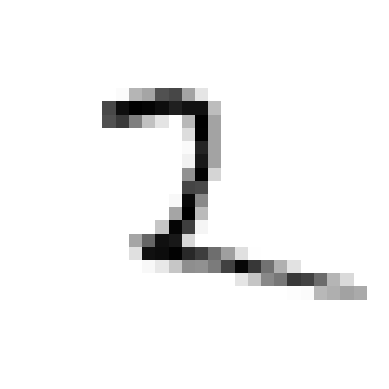

In [9]:
some_digit = X[30596]
plot_digit(some_digit)
plt.show()

In [10]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [11]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [12]:
from sklearn.linear_model import SGDClassifier

In [13]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [14]:
sgd_clf.predict([some_digit])

array([False])

## Performance Measures

In [15]:
from sklearn.model_selection import cross_val_score

In [16]:
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [17]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train))) 

False


In [18]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

In [19]:
##  Implementing Cross-Validation
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3)

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]
    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.95035
0.96035
0.9604


In [20]:
from sklearn.model_selection import cross_val_predict

In [21]:
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [22]:
y_train_pred.shape

(60000,)

In [23]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

In [24]:
y_train_perfect_predictions = y_train_5
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

In [25]:
from sklearn.metrics import precision_score, recall_score

In [26]:
precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [27]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

In [28]:
from sklearn.metrics import f1_score

In [29]:
f1_score(y_train_5, y_train_pred)

0.7325171197343847

In [30]:
y_scores = sgd_clf.decision_function([some_digit])

In [31]:
threshold = 0

In [32]:
y_some_digit_pred = (y_scores > threshold)

In [33]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

In [34]:
from sklearn.metrics import precision_recall_curve

In [35]:
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

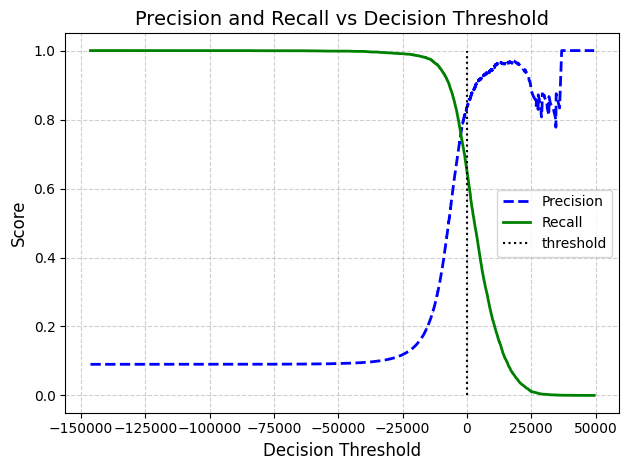

In [36]:
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")
plt.title("Precision and Recall vs Decision Threshold", fontsize=14)
plt.xlabel("Decision Threshold", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.legend(loc="best")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

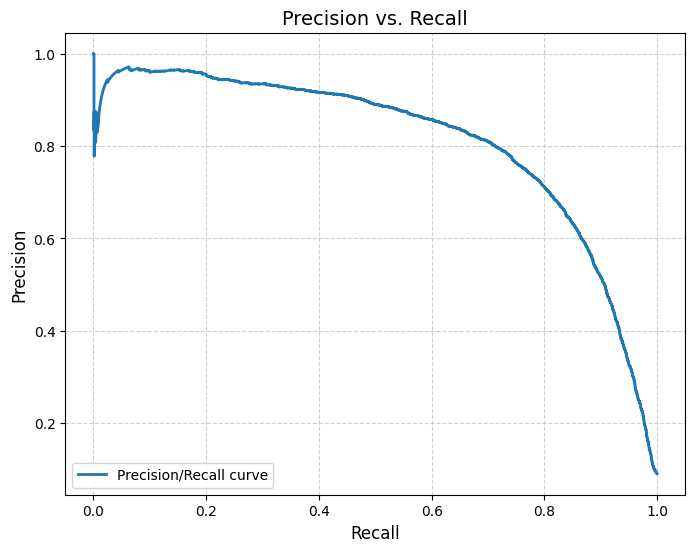

In [37]:
# Beautify the figure
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.title("Precision vs. Recall", fontsize=14)
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="lower left")


In [38]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.0194991439557)

In [39]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [40]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706

In [41]:
from sklearn.metrics import roc_curve

In [42]:
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

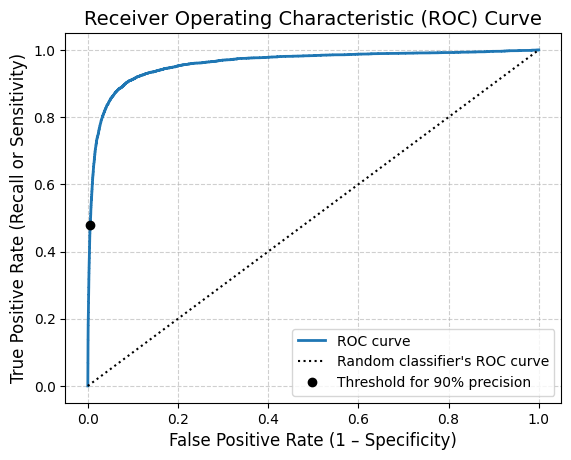

In [43]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")
# Beautify the figure
plt.title("Receiver Operating Characteristic (ROC) Curve", fontsize=14)
plt.xlabel("False Positive Rate (1 – Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Recall or Sensitivity)", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [44]:
from sklearn.metrics import roc_auc_score

In [45]:
roc_auc_score(y_train_5, y_scores)

0.9604938554008616

In [46]:
from sklearn.ensemble import RandomForestClassifier

In [47]:
forest_clf = RandomForestClassifier(random_state=42)

In [48]:
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")

In [49]:
y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
y_train_5, y_scores_forest)

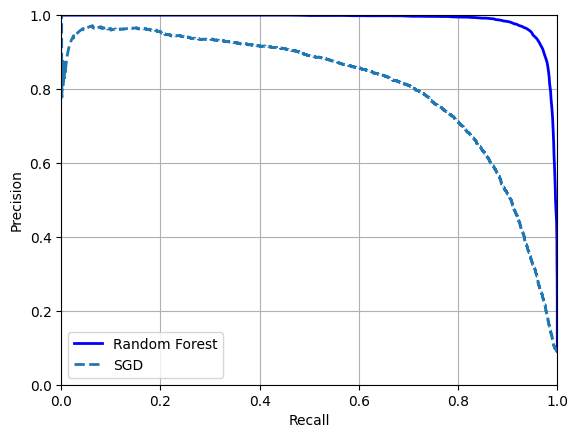

In [51]:
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")
# extra code – just beautifies and saves Figure 3–8
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
plt.show()

In [74]:
y_train_pred_forest = y_probas_forest[:, 1] >= 0.9  # positive proba ≥ 50%
f1_score(y_train_5, y_train_pred_forest)

0.5328822733423545

In [75]:
roc_auc_score(y_train_5, y_train_pred_forest)

0.6816085593064011

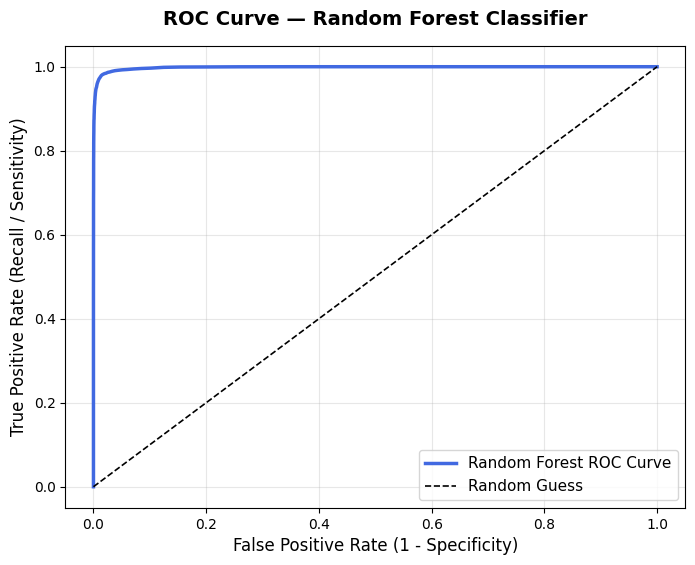

In [78]:
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores_forest)
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='royalblue', linewidth=2.5, label='Random Forest ROC Curve')

# Add diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Guess')

# Customize chart
plt.title("ROC Curve — Random Forest Classifier", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Recall / Sensitivity)", fontsize=12)
plt.legend(loc='lower right', fontsize=11, frameon=True)
plt.grid(alpha=0.3)